In [168]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [169]:
df = pd.read_csv('hearing_test.csv')
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [170]:
df.info

<bound method DataFrame.info of        age  physical_score  test_result
0     33.0            40.7            1
1     50.0            37.2            1
2     52.0            24.7            0
3     56.0            31.0            0
4     35.0            42.9            1
...    ...             ...          ...
4995  73.0             3.9            0
4996  57.0            33.9            1
4997  49.0            34.5            1
4998  38.0            46.4            1
4999  48.0            38.5            1

[5000 rows x 3 columns]>

In [171]:
df['test_result'].value_counts()

1    3000
0    2000
Name: test_result, dtype: int64

<Axes: xlabel='test_result', ylabel='age'>

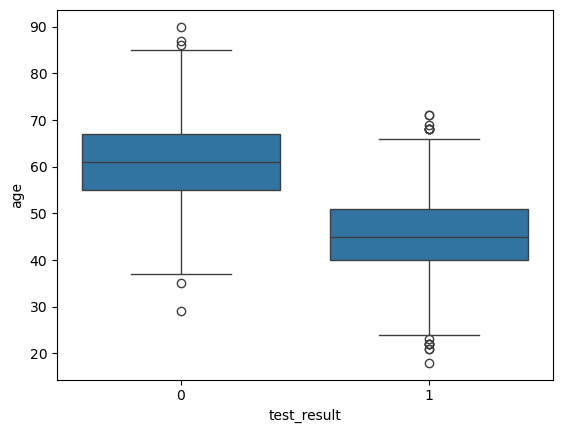

In [172]:
sns.boxplot(data= df, x = 'test_result', y = 'age')

<Axes: xlabel='test_result', ylabel='physical_score'>

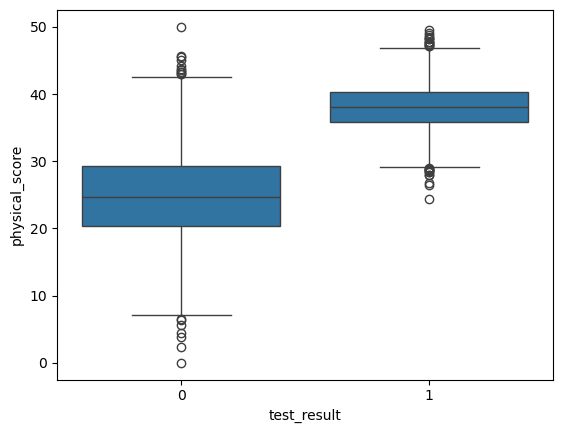

In [173]:
sns.boxplot(data= df, x = 'test_result', y ='physical_score')

In [174]:
df.info

<bound method DataFrame.info of        age  physical_score  test_result
0     33.0            40.7            1
1     50.0            37.2            1
2     52.0            24.7            0
3     56.0            31.0            0
4     35.0            42.9            1
...    ...             ...          ...
4995  73.0             3.9            0
4996  57.0            33.9            1
4997  49.0            34.5            1
4998  38.0            46.4            1
4999  48.0            38.5            1

[5000 rows x 3 columns]>

<Axes: xlabel='age', ylabel='physical_score'>

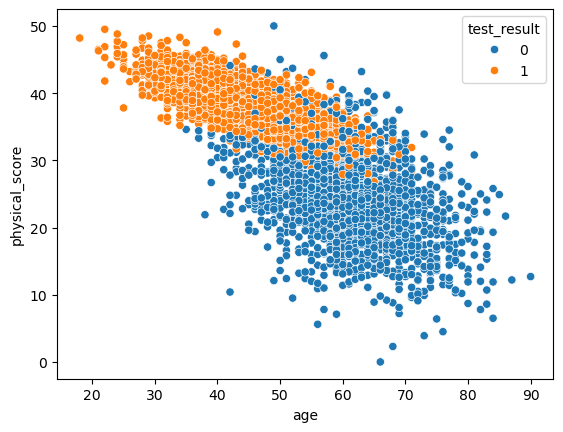

In [175]:
sns.scatterplot(data= df, hue = 'test_result', y ='physical_score', x='age')

In [176]:
df.corr()

,age,physical_score,test_result
age,1.000000,-0.782146,-0.683171
physical_score,-0.782146,1.000000,0.792716
test_result,-0.683171,0.792716,1.000000


<Axes: xlabel='physical_score', ylabel='test_result'>

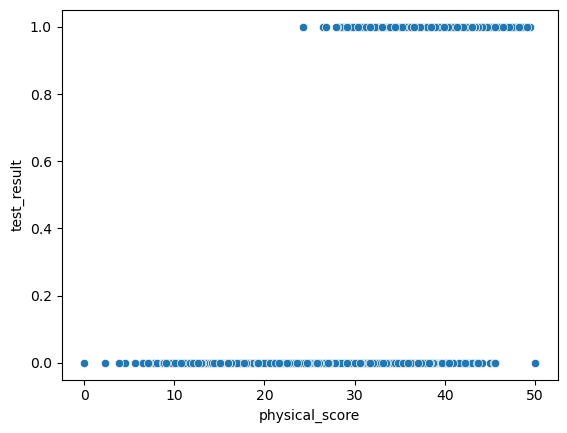

In [177]:
sns.scatterplot(data= df,x ='physical_score', y='test_result')

### Train Test Split and Scaling 

In [178]:
X = df.drop('test_result', axis  = 1)
y = df['test_result']

In [179]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [180]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 101)

In [181]:
sc = StandardScaler()

In [182]:
sc_X_train = sc.fit_transform(X_train)
sc_X_test = sc.transform(X_test) # For no data leakege 

### Logistic Regression Model

In [183]:
from sklearn.linear_model import LogisticRegression

In [184]:
#help(LogisticRegression)

In [185]:
log_model = LogisticRegression()

In [186]:
log_model.fit(sc_X_train, y_train)

LogisticRegression()

In [187]:
log_model.predict_proba(sc_X_test)

array([[0.02436668, 0.97563332],
       [0.02672574, 0.97327426],
       [0.9893468 , 0.0106532 ],
       ...,
       [0.02396838, 0.97603162],
       [0.94905149, 0.05094851],
       [0.22356825, 0.77643175]])

In [188]:
log_model.predict(sc_X_test)

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,

In [189]:
log_model.coef_

array([[-0.9039212 ,  3.48681952]])

* This coeff says the odds of label corresponds to particular feature.
* For theory u have to go through the p-pt notes. 

In [190]:
y_pred = log_model.predict(sc_X_test)

In [191]:
y_pred.shape

(1000,)

In [192]:
### Model performance:

In [237]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay,auc, roc_curve, roc_auc_score

In [238]:
accuracy_score(y_test, y_pred)

0.917

In [239]:
cm = confusion_matrix(y_test, y_pred)

In [240]:
cm

array([[332,  56],
       [ 27, 585]])

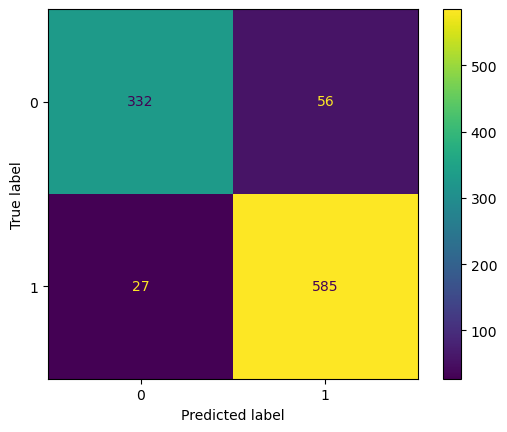

In [241]:
ConfusionMatrixDisplay(cm).plot()

In [242]:
cm

array([[332,  56],
       [ 27, 585]])

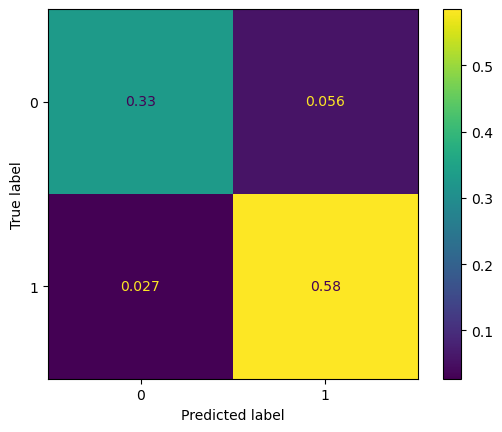

In [243]:
cm1 = confusion_matrix(y_test, y_pred, normalize= 'all')
ConfusionMatrixDisplay(cm1).plot()

In [244]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.92      0.86      0.89       388\n           1       0.91      0.96      0.93       612\n\n    accuracy                           0.92      1000\n   macro avg       0.92      0.91      0.91      1000\nweighted avg       0.92      0.92      0.92      1000\n'

### Precision, Recall, and F1-score

When evaluating a classification model, three common metrics are:

- **Precision**  
  Out of all the positive predictions the model made, how many were actually correct.  
  \[
  \text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}
  \]  
  - High precision means fewer false positives.

- **Recall (Sensitivity or True Positive Rate)**  
  Out of all the actual positives, how many did the model correctly identify.  
  \[
  \text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}
  \]  
  - High recall means fewer false negatives.

- **F1-score**  
  The harmonic mean of precision and recall, balancing the two.  
  \[
  F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}
  \]  
  - Useful when you want a balance between precision and recall, especially with imbalanced datasets.


### Accuracy, Precision, Recall, and F1-score

These are common metrics for evaluating classification models:

- **Accuracy**  
  The proportion of all predictions that were correct.  
  \[
  \text{Accuracy} = \frac{\text{True Positives + True Negatives}}{\text{Total Predictions}}
  \]  
  - Easy to understand, but can be misleading if the data is imbalanced (e.g., 95% of samples belong to one class).

- **Precision**  
  Out of all the positive predictions the model made, how many were actually correct.  
  \[
  \text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}
  \]  
  - High precision = few false positives.

- **Recall (Sensitivity or True Positive Rate)**  
  Out of all the actual positives, how many did the model correctly identify.  
  \[
  \text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}
  \]  
  - High recall = few false negatives.

- **F1-score**  
  The harmonic mean of precision and recall.  
  \[
  F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}
  \]  
  - Useful when you want a balance between precision and recall, especially with imbalanced datasets.


In [245]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       388
           1       0.91      0.96      0.93       612

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.92      0.92      1000



In [246]:
X_test

,age,physical_score
1718,39.0,37.8
2511,45.0,38.7
345,56.0,21.8
2521,40.0,44.0
54,64.0,25.4
...,...,...
3900,71.0,23.3
3753,51.0,32.6
3582,42.0,38.4
2392,52.0,24.8


### Testing for new person

In [247]:
new_Data = sc.transform([[46,12], [12, 50],[55, 35],[55, 33]]) # Scale the input 

new_Data

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.51302837, -2.54490641],
       [-3.52628075,  2.1271338 ],
       [ 0.28459726,  0.2829074 ],
       [ 0.28459726,  0.03701055]])

In [248]:
log_model.predict(new_Data)

array([0, 1, 1, 1])

In [249]:
log_model.predict_proba(new_Data) # it says how many percent he fails the test and how many % he pass the test 

array([[9.99640822e-01, 3.59177785e-04],
       [1.53716565e-05, 9.99984628e-01],
       [2.30099079e-01, 7.69900921e-01],
       [4.13296606e-01, 5.86703394e-01]])

### ROC/AUC
### ROC and AUC

- **ROC (Receiver Operating Characteristic) Curve**  
  The ROC curve is a plot that shows the performance of a classification model at different thresholds.  
  - **X-axis:** False Positive Rate (FPR) = FP / (FP + TN)  
  - **Y-axis:** True Positive Rate (TPR) = Recall = TP / (TP + FN)  
  - Each point on the ROC curve corresponds to a different decision threshold.

- **AUC (Area Under the Curve)**  
  The AUC is the area under the ROC curve.  
  - Ranges from **0 to 1**.  
  - **AUC = 0.5** → Model is no better than random guessing.  
  - **AUC close to 1.0** → Model has excellent separability (it can distinguish between classes well).  
  - **AUC close to 0.0** → Model is predicting the opposite of the true labels.

**Interpretation**  
- ROC curve: Visual way to see trade-off between sensitivity (recall) and specificity.  
- AUC: A single number summary of how good the model is across all thresholds.


In [250]:
log_model.predict_proba(sc_X_test)

array([[0.02436668, 0.97563332],
       [0.02672574, 0.97327426],
       [0.9893468 , 0.0106532 ],
       ...,
       [0.02396838, 0.97603162],
       [0.94905149, 0.05094851],
       [0.22356825, 0.77643175]])

In [251]:
#log_model.predict_proba(sc_X_test)[:,1]

In [252]:
y_score = log_model.predict_proba(sc_X_test)[:,1]

In [253]:
#roc_curve(y_test, y_score)

In [254]:
fpr, tpr, _ = roc_curve(y_test, y_score) # _ means here no need to show threshold. 

In [256]:
auc(fpr, tpr)

0.9625151607034568

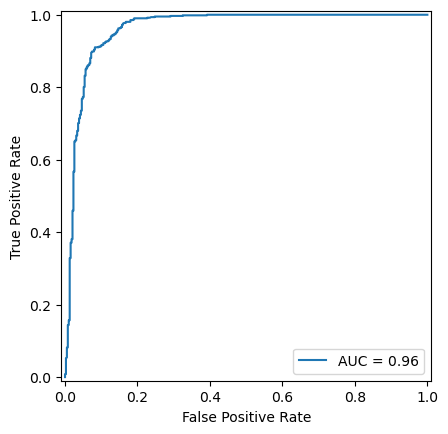

In [257]:
RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc= auc(fpr, tpr)).plot()

* Note this one for particular random_seed(101)